# OPERA DSWx (S2 HLS)

In this notebook we are going to download water masks (Dynamic Surface Water - DSW) from OPERA project. There are 2 good references:
* https://github.com/OPERA-Cal-Val/OPERA_Applications/blob/main/DSWx/Mosaics/notebooks/Create-mosaics.ipynb
* https://github.com/OPERA-Cal-Val/OPERA_Applications/blob/main/DSWx/Discover/Stream_and_Viz_DSWx-HLS_viaCMR-STAC.ipynb


## Earthaccess

We will first, try to download what we want by using `earthaccess`.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import earthaccess
import geopandas as gpd
import hvplot.xarray  # noqa: F401
import pandas as pd
import rasterio as rio
import rioxarray as xrio
import xarray as xr
from bokeh.models import FixedTicker

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.opera import (
    calc_aoi_stats,
    fill_df_with_stats,
    opera_results_to_df,
    search_opera,
)
from swot_toolkit.swot import auth_earthaccess


In [2]:
auth_earthaccess()

## Open the AOI

In [3]:
# Read geometry from a KML file
AOIs = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")
# Define the date range and Sentinel-2 tile
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

if AOIs is not None:
    AOI = AOIs[0]

## Search OPERA images

In [28]:
opera_items = search_opera(
    aoi=AOI.centroid,
    date_range=(START_DATE, END_DATE),
)

len(opera_items)

241

In [29]:
opera_df = opera_results_to_df(opera_items)
opera_df

,tile,date_str,satellite,item,datetime
date,,,,,
2024-01-04,T21MYS,20240104T140701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-04 14:07:01
2024-01-11,T21MYS,20240111T135701Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-11 13:57:01
2024-01-16,T21MYS,20240116T135659Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-16 13:56:59
2024-01-19,T21MYS,20240119T140709Z,S2B,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-19 14:07:09
2024-01-21,T21MYS,20240121T135651Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-21 13:56:51
...,...,...,...,...,...
2025-06-26,T21MYS,20250626T140111Z,S2A,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-26 14:01:11
2025-06-27,T21MYS,20250627T141111Z,S2C,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-27 14:11:11
2025-06-29,T21MYS,20250629T135408Z,L8,"{'meta': {'concept-type': 'granule', 'concept-...",2025-06-29 13:54:08


In [9]:
opera_df = fill_df_with_stats(
    opera_df=opera_df,
    aoi=AOI,
    use_bounds=True,
    crs="epsg:4326",
    columns=["perc_valid"],
)

Calculating stats for OPERA:   0%|          | 0/241 [00:00<?, ?it/s]

In [12]:
opera_df.sort_values(by="perc_valid", ascending=False).iloc[:20]

,tile,date_str,satellite,item,datetime,perc_valid
date,,,,,,
2024-11-10,T21MYS,20241110T134813Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2024-11-10 13:48:13,99.98
2024-09-23,T21MYS,20240923T134806Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2024-09-23 13:48:06,99.34
2024-08-08,T21MYS,20240808T140051Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-08-08 14:00:51,98.93
2024-07-19,T21MYS,20240719T135701Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-07-19 13:57:01,97.92
2024-09-02,T21MYS,20240902T135709Z,S2B,{'meta': {'collection-concept-id': 'C261712667...,2024-09-02 13:57:09,95.84
2024-09-27,T21MYS,20240927T135701Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-09-27 13:57:01,86.89
2024-07-21,T21MYS,20240721T134748Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2024-07-21 13:47:48,84.45
2024-08-06,T21MYS,20240806T134745Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2024-08-06 13:47:45,82.20
2024-11-06,T21MYS,20241106T135701Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-11-06 13:57:01,78.97


In [4]:
# opera_df.to_parquet("/data/swot/tmp/OPERA_S2_Valid_Pxls_Curua_Una.parquet")
opera_df = pd.read_parquet("/data/swot/tmp/OPERA_S2_Valid_Pxls_Curua_Una.parquet")

In [37]:
opera_df

,tile,date_str,satellite,item,datetime,perc_valid
date,,,,,,
2024-01-04,T21MYS,20240104T140701Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-01-04 14:07:01,0.00
2024-01-11,T21MYS,20240111T135701Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-01-11 13:57:01,7.10
2024-01-16,T21MYS,20240116T135659Z,S2B,{'meta': {'collection-concept-id': 'C261712667...,2024-01-16 13:56:59,10.18
2024-01-19,T21MYS,20240119T140709Z,S2B,{'meta': {'collection-concept-id': 'C261712667...,2024-01-19 14:07:09,0.00
2024-01-21,T21MYS,20240121T135651Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2024-01-21 13:56:51,1.86
...,...,...,...,...,...,...
2025-06-26,T21MYS,20250626T140111Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2025-06-26 14:01:11,8.91
2025-06-27,T21MYS,20250627T141111Z,S2C,{'meta': {'collection-concept-id': 'C261712667...,2025-06-27 14:11:11,0.00
2025-06-29,T21MYS,20250629T135408Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2025-06-29 13:54:08,0.00


In [13]:
from swot_toolkit.utils import find_closest_items

In [34]:
closest_items = find_closest_items("2025-05-26", opera_df)
closest_items

,tile,date_str,satellite,item,datetime,perc_valid,delta
date,,,,,,,
2025-05-25,T21MYS,20250525T135721Z,S2C,{'meta': {'collection-concept-id': 'C261712667...,2025-05-25 13:57:21,6.15,-1 days +13:57:21
2025-05-27,T21MYS,20250527T140111Z,S2A,{'meta': {'collection-concept-id': 'C261712667...,2025-05-27 14:01:11,6.67,1 days 14:01:11
2025-05-23,T21MYS,20250523T140709Z,S2B,{'meta': {'collection-concept-id': 'C261712667...,2025-05-23 14:07:09,0.00,-3 days +14:07:09
2025-05-28,T21MYS,20250528T135352Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2025-05-28 13:53:52,0.00,2 days 13:53:52
2025-05-28,T21MYS,20250528T140811Z,S2C,{'meta': {'collection-concept-id': 'C261712667...,2025-05-28 14:08:11,0.00,2 days 14:08:11
2025-05-28,T21MYS,20250528T135352Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2025-05-28 13:53:52,0.00,2 days 13:53:52
2025-05-28,T21MYS,20250528T140811Z,S2C,{'meta': {'collection-concept-id': 'C261712667...,2025-05-28 14:08:11,0.00,2 days 14:08:11
2025-05-21,T21MYS,20250521T134739Z,L8,{'meta': {'collection-concept-id': 'C261712667...,2025-05-21 13:47:39,0.00,-5 days +13:47:39
2025-05-30,T21MYS,20250530T135709Z,S2B,{'meta': {'collection-concept-id': 'C261712667...,2025-05-30 13:57:09,25.71,4 days 13:57:09


## Open the SWOT mosaics

In [ ]:
mosaics_path = Path("/data/swot/mosaics")
mosaic_files = list(mosaics_path.glob("*.parquet"))

mosaics = {file.stem.split("_")[-1]: file for file in mosaic_files}

In [ ]:
data = {}
for file in mosaic_files:
    mosaic = gpd.read_parquet(file)

    date = file.stem.split("_")[-1]  # Extract date from filename

    data[date] = {
        classes: len(mosaic[mosaic["classes"].astype("str") == classes])
        for classes in mosaic["classes"].astype("str").unique()
    }

mosaics_df = pd.DataFrame(data).T
mosaics_df["total"] = mosaics_df.sum(axis=1)
mosaics_df

In [6]:
mosaics_df["date"] = pd.to_datetime(mosaics_df.index)

In [ ]:
from swot_toolkit.utils import (
    match_datasets_by_time,
)


In [14]:
matched_df = match_datasets_by_time(
    reference_df=mosaics_df,
    target_df=opera_df,
    ref_date_col="date",
    target_date_col="datetime",
    max_time_delta=10,
    quality_col="perc_valid",
    strategy="best_quality",
)

Matching datasets:   0%|          | 0/22 [00:00<?, ?it/s]

In [341]:
matched_df.sort_values("perc_valid", ascending=False).iloc[:10][["datetime", "perc_valid"]]

,,datetime,perc_valid
index,delta,,
20240914,9 days 13:48:06,2024-09-23 13:48:06,99.34
20241001,-8 days +13:48:06,2024-09-23 13:48:06,99.34
20240713,6 days 13:57:01,2024-07-19 13:57:01,97.92
20240824,9 days 13:57:09,2024-09-02 13:57:09,95.84
20240622,2 days 13:57:09,2024-06-24 13:57:09,53.99
20241025,7 days 13:56:59,2024-11-01 13:56:59,48.92
20241206,-5 days +13:57:09,2024-12-01 13:57:09,41.94
20240331,0 days 13:57:01,2024-03-31 13:57:01,30.43
20250320,-9 days +13:57:09,2025-03-11 13:57:09,24.86


## Plot Matches

In [ ]:
import matplotlib.pyplot as plt

from swot_toolkit.opera import open_opera_mask, plot_opera_array


In [21]:
DATE = "20240914"


In [23]:
mosaic = gpd.read_parquet(mosaics[DATE])

In [37]:
opera_date = matched_df.loc[DATE]["datetime"].iloc[0]
opera_date

Timestamp('2024-09-23 13:48:06')

In [40]:
opera_item = opera_df[opera_df["datetime"] == opera_date].iloc[0]["item"]

In [ ]:
array = open_opera_mask(opera_item)

In [336]:
array = array.rio.clip_box(*AOI.bounds, crs="epsg:4326")

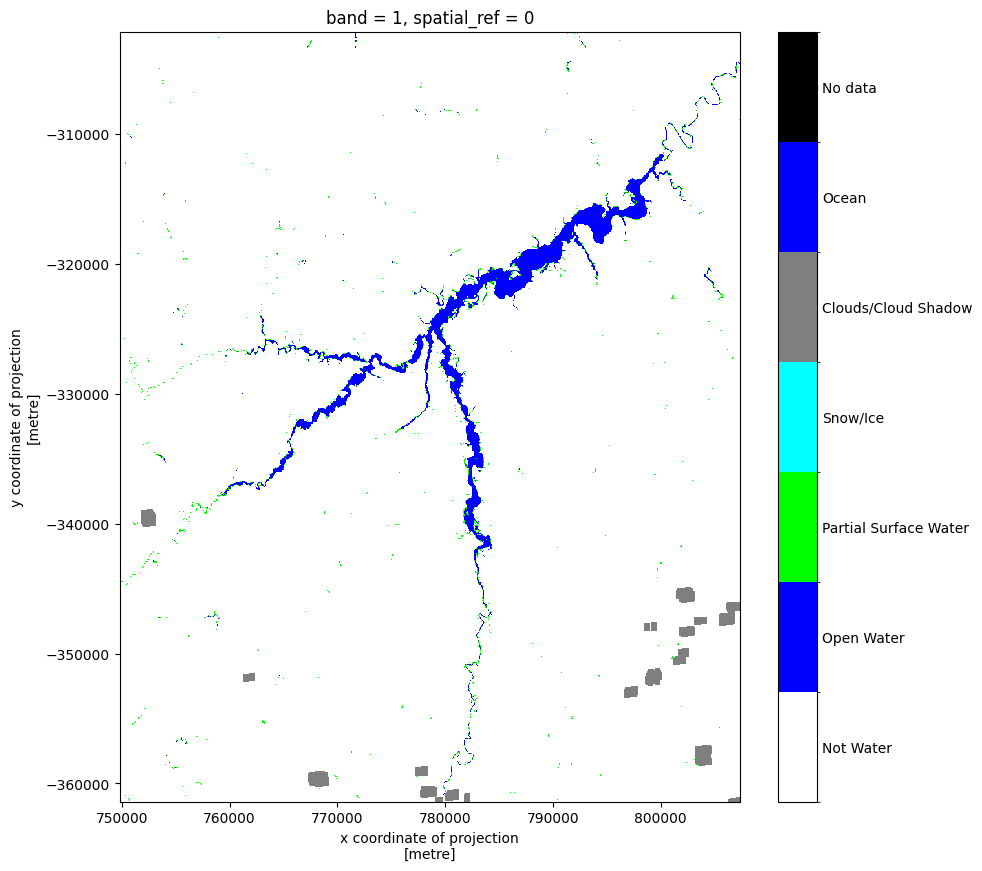

In [338]:
ax = plot_opera_array(array)

## Compare masks

In [155]:
files = earthaccess.open([opera_item])

QUEUEING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/10 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
ds = rio.open(files[0])

In [182]:
mosaic = mosaic.to_crs(array.rio.crs)

In [241]:
POINTS = 2000000
xs = mosaic.geometry.x[:POINTS]
ys = mosaic.geometry.y[:POINTS]


In [242]:
mosaic["OPERA_class"] = [x.item() for x in ds.sample(zip(xs, ys))]

In [244]:
mosaic["OPERA_labels"] = mosaic["OPERA_class"].map(OPERA_LABELS)

In [304]:
# The final results will depend on how we consider water in swot
# So, here we will map swot labels to match opera
swot_water_mapping = {
    "land": "Not Water",
    "land_near_water": "Not Water",
    "water_near_land": "Not Water",
    "low_coh_water_near_land": "Not Water",
    "open_water": "Open Water",
    "open_low_coh_water": "Not Water",
    "dark_water": "Open Water",
}

opera_water_mapping = {
    "Not Water": "Not Water",
    "Open Water": "Open Water",
    "Partial Surface Water": "Open Water",
    "Snow/Ice": "Not Water",
    "Clouds/Cloud Shadow": pd.NA,
    "Ocean": "Open Water",
    "No data": pd.NA,
}

In [305]:
mosaic["swot_mapped_classes"] = mosaic["classes"].map(swot_water_mapping)

In [306]:
mosaic["opera_mapped_classes"] = mosaic["OPERA_labels"].map(opera_water_mapping)


In [307]:
# To compute a confusion matrix, let's assume OPERA as the ground_truth
true_positives = (mosaic["swot_mapped_classes"] == "Open Water") & (
    mosaic["opera_mapped_classes"] == "Open Water"
)

true_negatives = (mosaic["swot_mapped_classes"] == "Not Water") & (
    mosaic["opera_mapped_classes"] == "Not Water"
)

comission_errors = (mosaic["swot_mapped_classes"] == "Open Water") & (
    mosaic["opera_mapped_classes"] == "Not Water"
)

omission_errors = (mosaic["swot_mapped_classes"] == "Not Water") & (
    mosaic["opera_mapped_classes"] == "Open Water"
)

no_data = pd.isna(mosaic["opera_mapped_classes"])

In [308]:
# Assign status for each type of prediction
mosaic.loc[comission_errors, "status"] = "Commission"
mosaic.loc[omission_errors, "status"] = "Omission"
mosaic.loc[true_positives, "status"] = "True Positive"
mosaic.loc[true_negatives, "status"] = "True Negative"
mosaic.loc[no_data, "status"] = "No Data"


In [298]:
from matplotlib.colors import ListedColormap

<Axes: >

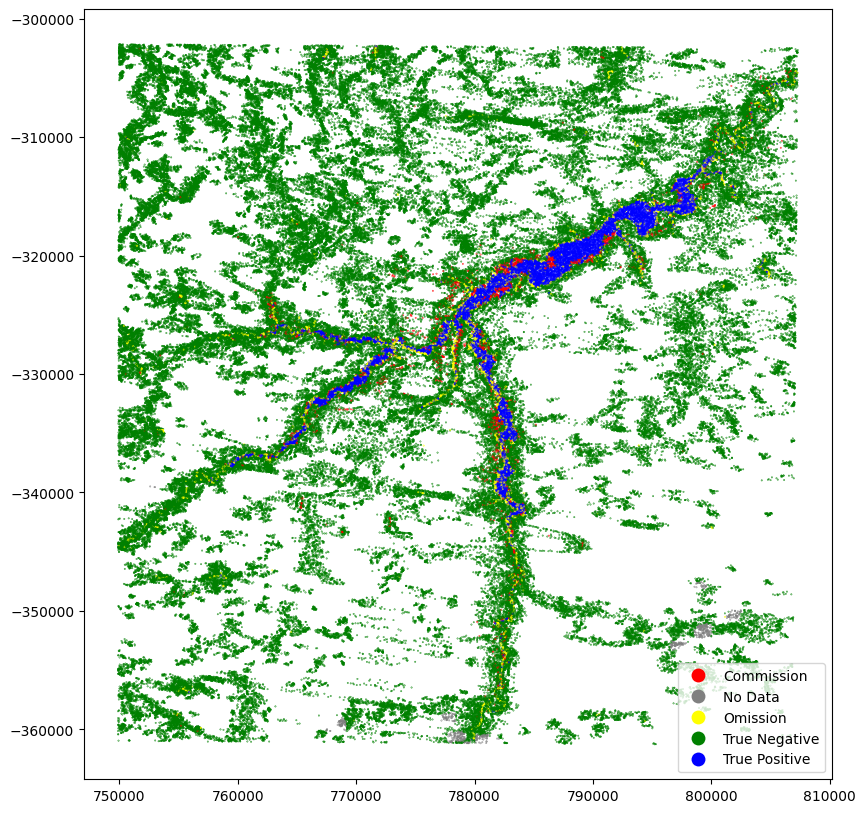

In [339]:
mosaic.sample(200000).plot(
    markersize=0.1,
    column="status",
    legend=True,
    cmap=ListedColormap(["red", "grey", "yellow", "green", "blue"]),
    figsize=(10, 10),
)

In [309]:
# Calculate precision and recall
precision = true_positives.sum() / (true_positives.sum() + comission_errors.sum())
recall = true_positives.sum() / (true_positives.sum() + omission_errors.sum())
f1_score = 2 * (precision * recall) / (precision + recall)

In [310]:
# Create a dataframe with the results
cm = pd.DataFrame(
    {
        "Type": [
            "True Positives",
            "True Negatives",
            "Commissions",
            "Omissions",
            "Precision",
            "Recall",
            "F1-Score",
        ],
        "Count": [
            str(true_positives.sum()),
            str(true_negatives.sum()),
            str(comission_errors.sum()),
            str(omission_errors.sum()),
            precision,
            recall,
            f1_score,
        ],
    }
)

cm

,Type,Count
0,True Positives,148124
1,True Negatives,1606765
2,Commissions,36890
3,Omissions,79371
4,Precision,0.80061
5,Recall,0.651109
6,F1-Score,0.718161


In [327]:
import numpy as np
from sklearn.metrics import f1_score


In [ ]:
# mosaic.loc[pd.isna(mosaic["opera_mapped_classes"]), "opera_mapped_classes"] = "No Data"

In [316]:
opera_classes = mosaic.loc[~pd.isna(mosaic["opera_mapped_classes"]), "opera_mapped_classes"]

In [317]:
swot_classes = mosaic.loc[~pd.isna(mosaic["opera_mapped_classes"]), "swot_mapped_classes"]

In [ ]:
f1_score(
    opera_classes.map({"Open Water": 1, "Not Water": 0}).to_numpy(),
    swot_classes.map({"Open Water": 1, "Not Water": 0}).to_numpy(),
)

0.7181613007231358

In [328]:
f1_score([0, 0, 0, 1], [1, 1, 1, 1])

0.4

In [324]:
opera_classes.map({"Open Water": 1, "Not Water": 0}).to_numpy()

array([1, 0, 0, ..., 0, 0, 0])

In [330]:
f1_score(opera_classes, swot_classes, pos_label="Open Water")

0.7181613007231358

In [285]:
mosaic.groupby("status").count()

,height,geoid,classification,coherent_power,sig0,latitude,longitude,geometry,classes,OPERA_class,OPERA_labels,swot_mapped_classes,opera_mapped_classes
status,,,,,,,,,,,,,
Commission,161234,161234,161234,161234,161233,161234,161234,161234,161234,161234,161234,161234,161234
No Data,6886,6886,6886,6886,6886,6886,6886,6886,6886,6886,6886,6886,0
Omission,58768,58768,58768,58768,58766,58768,58768,58768,58768,58768,58768,58768,58768
True Negative,1482421,1482421,1482421,1482421,1482408,1482421,1482421,1482421,1482421,1482421,1482421,1482421,1482421
True Positive,168727,168727,168727,168727,168727,168727,168727,168727,168727,168727,168727,168727,168727


In [275]:
mosaic["opera_mapped_classes"].count()

1871150

In [274]:
len(mosaic)

1878036

In [267]:
true_negatives.sum() / len(mosaic)

0.7893464236042333

In [266]:
true_positives.sum() / len(mosaic)

0.08984226074473546

In [216]:
list(ds.sample([(xs[0], ys[0]), (xs[1], ys[1])], indexes=1))

[array([1], dtype=uint8), array([0], dtype=uint8)]

In [211]:
values

[array([1], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], dtype=uint8),
 array([0], 

In [201]:
ds_array = ds.read()

In [202]:
ds_array

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)

In [196]:
array = array.load()

In [194]:
array.sel(x=740000, y=-350000, method="nearest").values[0]

0

In [163]:
import rasterio as rio
import rioxarray as xrio

In [165]:
array.rio.sample?


Object `array.rio.sample` not found.


In [161]:
dir(array.rio)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cached_transform',
 '_check_dimensions',
 '_count',
 '_create_dst_data',
 '_crs',
 '_gcps',
 '_get_dst_nodata',
 '_get_obj',
 '_height',
 '_internal_bounds',
 '_interpolate_na',
 '_manager',
 '_nodata',
 '_obj',
 '_set_crs',
 '_unordered_bounds',
 '_width',
 '_x_dim',
 '_y_dim',
 'bounds',
 'clip',
 'clip_box',
 'count',
 'crs',
 'encoded_nodata',
 'estimate_utm_crs',
 'get_gcps',
 'grid_mapping',
 'height',
 'interpolate_na',
 'isel_window',
 'nodata',
 'pad_box',
 'pad_xy',
 'reproject',
 'reproject_match',
 'resolution',
 'set_attrs',
 'set_crs',
 'set_encoding',
 'set_nodata',
 'set_spatial_dims',
 

In [158]:
ds = rio.open(files[0])

In [159]:
type(ds)

rasterio.io.DatasetReader

In [154]:
mosaic

,height,geoid,classification,coherent_power,sig0,latitude,longitude,geometry,classes
0,83.763176,-18.074703,1,277352.343750,-0.001955,-3.263421,-54.745281,POINT (-54.74528 -3.26342),land
1,41.264908,-18.068773,1,308442.843750,0.140939,-3.260531,-54.748749,POINT (-54.74875 -3.26053),land
2,43.419125,-18.067976,1,142167.515625,-0.055107,-3.260395,-54.749668,POINT (-54.74967 -3.2604),land
3,46.774208,-18.067650,1,157423.796875,-0.001851,-3.260183,-54.749760,POINT (-54.74976 -3.26018),land
4,41.521069,-18.068680,1,191320.000000,-0.014045,-3.260358,-54.748573,POINT (-54.74857 -3.26036),land
...,...,...,...,...,...,...,...,...,...
1878031,176.026688,-18.833685,1,119696.406250,-0.253344,-3.260740,-54.245850,POINT (-54.24585 -3.26074),land
1878032,176.999283,-18.839001,1,169679.390625,-0.182475,-3.260671,-54.244038,POINT (-54.24404 -3.26067),land
1878033,176.681412,-18.837345,1,202029.359375,0.951876,-3.260759,-54.244633,POINT (-54.24463 -3.26076),land
1878034,176.094421,-18.836735,1,163448.984375,1.180207,-3.260791,-54.244854,POINT (-54.24485 -3.26079),land
